<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/CUSTOMER_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated dataset shape: (300, 2)
Converged in 10 iterations
Final centroids:
[[-2.08022823 -1.52673724]
 [-2.0570587  -2.49024653]
 [ 1.0249634   2.97516449]]


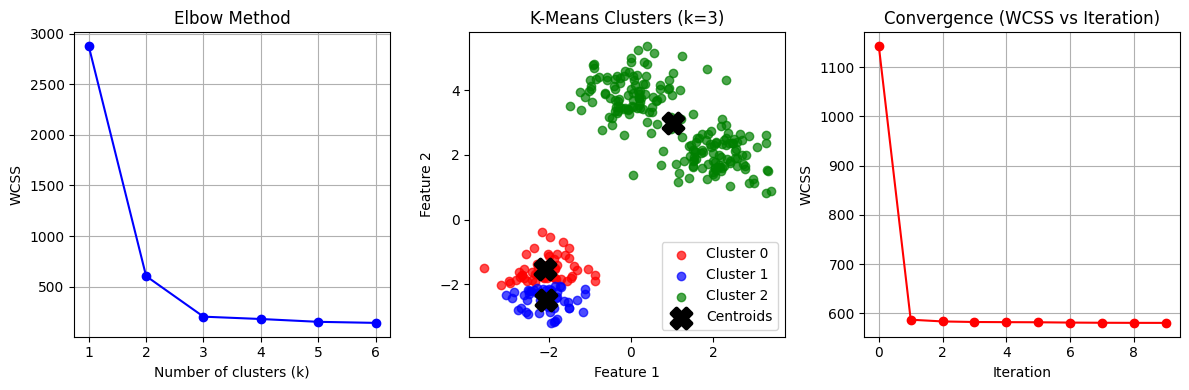

In [21]:
# K-Means Clustering from Scratch - Pure NumPy Implementation
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D dataset with 3 clear clusters (pure NumPy)
def generate_synthetic_data(n_samples=300, n_clusters=3, random_state=42):
    np.random.seed(random_state)
    centers = np.array([[-2, -2], [2, 2], [0, 4]])
    X = []
    for i, center in enumerate(centers):
        cluster_points = np.random.normal(center, 0.6, (n_samples//n_clusters, 2))
        X.append(cluster_points)
    return np.vstack(X)

X = generate_synthetic_data()
print(f"Generated dataset shape: {X.shape}")

class KMeansScratch:
    def __init__(self, k, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.wcss_history = []

    def fit(self, X):
        # Initialize centroids randomly from data
        idx = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[idx].copy()

        for iteration in range(self.max_iters):
            # Assign clusters (compute distances)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            # Update centroids (mean of assigned points)
            new_centroids = np.array([X[self.labels == i].mean(axis=0)
                                    if np.sum(self.labels == i) > 0
                                    else self.centroids[i]
                                    for i in range(self.k)])

            # Compute WCSS
            wcss = 0
            for i in range(self.k):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    wcss += np.sum((cluster_points - self.centroids[i])**2)
            self.wcss_history.append(wcss)

            # Check convergence
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            if shift < self.tol:
                break

        return self

# Run K-Means with k=3
kmeans = KMeansScratch(k=3)
kmeans.fit(X)
print(f"Converged in {len(kmeans.wcss_history)} iterations")
print(f"""Final centroids:
{kmeans.centroids}""")

# Elbow method: test k=1 to 6
wcss_values = []
for k in range(1, 7):
    model = KMeansScratch(k=k)
    model.fit(X)
    wcss_values.append(model.wcss_history[-1])

# Plot 1: Elbow curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, 7), wcss_values, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)

# Plot 2: Final clusters
plt.subplot(1, 3, 2)
colors = ['red', 'blue', 'green']
for i in range(3):
    plt.scatter(X[kmeans.labels == i, 0], X[kmeans.labels == i, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.7)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='black', s=200, marker='X', linewidths=3, label='Centroids')
plt.title('K-Means Clusters (k=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot 3: WCSS convergence
plt.subplot(1, 3, 3)
plt.plot(kmeans.wcss_history, 'ro-')
plt.title('Convergence (WCSS vs Iteration)')
plt.xlabel('Iteration')
plt.ylabel('WCSS')
plt.grid(True)

plt.tight_layout()
plt.savefig('kmeans_results.png')  # Save for submission
plt.show()